# Évaluation de performance par market risk aversion

Notebook à placer dans le dossier `analyses/`.


In [68]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import calendar

# ============================
# Configuration de l'analyse
# ============================
# Le notebook est supposé être exécuté depuis le dossier:
#   analyses/
# avec results/ et data/ au même niveau que analyses/.
PROJECT_ROOT = Path("..").resolve()

START = "2015-01-01"
END   = "2025-06-30"

# Fenêtre utilisée dans les noms des fichiers de rendements générés par returns_from_weights.
# Les graphiques et métriques restent ensuite filtrés/alignés sur START/END.
RETURNS_FILE_START = "2015-01-01"
RETURNS_FILE_END   = "2025-06-30"

TAU = 0.001
tau = TAU  # compatibilité avec certaines cellules existantes

PORTFOLIO_RISK_AVERSION = 1

def _format_portfolio_risk_aversion(value) -> str:
    """Même convention que les scripts: 1.0 -> '1', 0.1 -> '0.1', 2.5 -> '2.5'."""
    try:
        return f"{float(value):g}"
    except Exception:
        return str(value).strip().replace(" ", "_")

RISK_AVERSION_LABEL = _format_portfolio_risk_aversion(PORTFOLIO_RISK_AVERSION)

DATA_DIR = PROJECT_ROOT / "data"
RESPONSES_PORTFOLIOS_DIR = PROJECT_ROOT / "responses_portfolios"
RESULTS_BASE_DIR = PROJECT_ROOT / "results"
RESULTS_DIR = RESULTS_BASE_DIR / f"portfolio_risk_aversion_{RISK_AVERSION_LABEL}"

# Versions string POSIX pour glob/read_csv.
DATA_DIR_STR = DATA_DIR.as_posix()
RESPONSES_PORTFOLIOS_DIR_STR = RESPONSES_PORTFOLIOS_DIR.as_posix()
RESULTS_DIR_STR = RESULTS_DIR.as_posix()

print(f"portfolio_risk_aversion analysé: {PORTFOLIO_RISK_AVERSION}")
print(f"Dossier de résultats utilisé: {RESULTS_DIR_STR}")

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Le dossier de résultats n'existe pas: {RESULTS_DIR}\n"
        "Vérifie que les poids/rendements ont été générés avec cette valeur de portfolio_risk_aversion."
    )


# ============================
# Modèles LLM inclus dans l'analyse
# ============================
# Le nouveau modèle GPT-5.4 mini peut être écrit de plusieurs façons selon le
# script utilisé pour générer les réponses/poids/rendements.
INCLUDE_GPT54MINI = True
GPT54MINI_PREFIXES = ["gpt54mini", "gpt-5.4-mini", "gpt-5.4-mini-2026-03-17"]


portfolio_risk_aversion analysé: 1
Dossier de résultats utilisé: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1


In [69]:
import os
import glob
import pandas as pd

PORT_DIR = RESPONSES_PORTFOLIOS_DIR_STR

def _find_date_col(df: pd.DataFrame) -> str:
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    # fallback: first unnamed index column
    if len(df.columns) > 0 and str(df.columns[0]).lower().startswith("unnamed"):
        df = df.rename(columns={df.columns[0]: "date_key"})
        return "date_key"
    raise ValueError(f"Aucune colonne de date trouvée. Colonnes: {list(df.columns)}")

def _read_and_standardize(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = _find_date_col(df)

    # Standardize to 'date_key' as datetime
    if date_col == "ym":
        # 'YYYY-MM' -> month start
        df["date_key"] = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        df["date_key"] = pd.to_datetime(df[date_col], errors="coerce")

    # drop original date cols (except date_key)
    drop_cols = [c for c in ["Date", "date", "ym"] if c in df.columns and c != "date_key"]
    df = df.drop(columns=drop_cols, errors="ignore")

    # keep only rows with date
    df = df.dropna(subset=["date_key"]).copy()
    return df

def combine_monthly_portfolios(
    pattern: str,
    out_path: str,
) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(PORT_DIR, pattern)))
    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé avec le pattern: {PORT_DIR}/{pattern}")

    dfs = []
    for f in files:
        df = _read_and_standardize(f)
        df["source_file"] = os.path.basename(f)  # pratique pour debug
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)

    # sort & drop duplicates by date (keep last)
    out = out.sort_values("date_key")
    out = out.drop_duplicates(subset=["date_key"], keep="last").reset_index(drop=True)

    # save combined
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    out.to_csv(out_path, index=False)
    return out

# ---- Build combined baseline files ----
eq_combined = combine_monthly_portfolios(
    pattern="equal_weighted_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"),
)

opt_combined = combine_monthly_portfolios(
    pattern="optimized_portfolio*.csv",
    out_path=os.path.join(PORT_DIR, "optimized_portfolio.csv"),
)

# print("Baselines combinés :")
# print(" -", os.path.join(PORT_DIR, "equal_weighted_portfolio.csv"), "(", len(eq_combined), "rows )")
# print(" -", os.path.join(PORT_DIR, "optimized_portfolio.csv"), "(", len(opt_combined), "rows )")
# display(eq_combined.head())
# display(opt_combined.head())


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

"""
Baselines portfolio returns (generated by baselines.py)
Expected files:
  - ../responses_portfolios/equal_weighted_portfolio.csv
  - ../responses_portfolios/optimized_portfolio.csv
"""
equal_weighted_portfolio_returns = pd.read_csv(RESPONSES_PORTFOLIOS_DIR / "equal_weighted_portfolio.csv")
optimized_portfolio_returns      = pd.read_csv(RESPONSES_PORTFOLIOS_DIR / "optimized_portfolio.csv")

# equal_weighted_portfolio_returns.head()
# optimized_portfolio_returns.tail()


## Chargement des poids et rendements Black-Litterman

In [71]:
import glob
import pandas as pd


def _glob_unique(patterns: list[str]) -> list[str]:
    files: list[str] = []
    for pat in patterns:
        files.extend(sorted(glob.glob(pat)))
    return sorted(set(files))


def _format_patterns(patterns: list[str]) -> str:
    return "\n".join(f"- {p}" for p in patterns)


def _select_preferred_file(candidates: list[str], exact_path: str | None = None) -> str:
    """Prefer the exact expected file when present; otherwise use the last sorted match."""
    if exact_path is not None and exact_path in candidates:
        return exact_path
    if not candidates:
        raise FileNotFoundError("No candidate file was found.")
    return candidates[-1]


def _read_weights_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    if "Date" in df.columns:
        date_col = "Date"
    elif "date_key" in df.columns:
        date_col = "date_key"
    else:
        date_col = df.columns[0]

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).set_index(date_col).sort_index()
    return df


def load_bl_weights(prefixes: list[str], label: str) -> tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Load BL monthly weights for one LLM family.

    prefixes supports aliases. For GPT-5.4 mini, this allows files generated as
    gpt54mini_..., gpt-5.4-mini_..., or gpt-5.4-mini-2026-03-17_...
    """
    patterns = []
    for prefix in prefixes:
        patterns.extend([
            f"{RESULTS_DIR_STR}/{prefix}_base_omega_1_black_litterman_market_implied_weights_tau_{TAU}.csv",
            f"{RESULTS_DIR_STR}/{prefix}_base_omega_1_black_litterman_market_implied_weights_tau_{TAU}_*.csv",
        ])

    candidates = _glob_unique(patterns)
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {label} weights CSV in {RESULTS_DIR_STR}/. Tried patterns:\n"
            + _format_patterns(patterns)
        )

    path = candidates[-1]
    weights_df = _read_weights_csv(path)
    results = weights_df.T
    print(f"{label} weights: {path}")
    return weights_df, results, path


def load_bl_returns(prefixes: list[str], label: str) -> tuple[pd.DataFrame, str]:
    """Load BL returns for one LLM family using all supported filename aliases."""
    patterns = []
    exact_candidates = []
    for prefix in prefixes:
        exact = (
            f"{RESULTS_DIR_STR}/{prefix}_base_omega_1_black_litterman_implied_weights_returns_tau_"
            f"{TAU}_{RETURNS_FILE_START}_{RETURNS_FILE_END}.csv"
        )
        exact_candidates.append(exact)
        patterns.extend([
            exact,
            f"{RESULTS_DIR_STR}/{prefix}_base_omega_1_black_litterman_implied_weights_returns_tau_{TAU}_*.csv",
            f"{RESULTS_DIR_STR}/{prefix}_base_omega_1_black_litterman_implied_weights_returns_tau_{TAU}.csv",
        ])

    candidates = _glob_unique(patterns)
    if not candidates:
        raise FileNotFoundError(
            f"Could not find {label} returns CSV in {RESULTS_DIR_STR}/. Tried patterns:\n"
            + _format_patterns(patterns)
            + "\nRun returns_from_weights.py first with the same --portfolio_risk_aversion."
        )

    exact_path = next((p for p in exact_candidates if p in candidates), None)
    path = _select_preferred_file(candidates, exact_path=exact_path)
    returns = pd.read_csv(path)
    print(f"{label} returns: {path}")
    return returns, path


def load_no_view_returns() -> tuple[pd.DataFrame, str]:
    patterns = [
        f"{RESULTS_DIR_STR}/none_black_litterman_implied_weights_returns_tau_{TAU}_{RETURNS_FILE_START}_{RETURNS_FILE_END}.csv",
        f"{RESULTS_DIR_STR}/none_black_litterman_implied_weights_returns_tau_{TAU}_*.csv",
        f"{RESULTS_DIR_STR}/None_black_litterman_implied_weights_returns_tau_{TAU}_*.csv",
        f"{RESULTS_DIR_STR}/none_black_litterman_implied_weights_returns_tau_{TAU}.csv",
        f"{RESULTS_DIR_STR}/None_black_litterman_implied_weights_returns_tau_{TAU}.csv",
        f"{RESULTS_DIR_STR}/none_black_litterman_returns_tau_{TAU}_*.csv",
        f"{RESULTS_DIR_STR}/None_black_litterman_returns_tau_{TAU}_*.csv",
        f"{RESULTS_DIR_STR}/none_black_litterman_returns_tau_{TAU}.csv",
        f"{RESULTS_DIR_STR}/None_black_litterman_returns_tau_{TAU}.csv",
    ]
    candidates = _glob_unique(patterns)
    if not candidates:
        raise FileNotFoundError(
            f"Could not find None/no-views returns CSV in {RESULTS_DIR_STR}/. Tried patterns:\n"
            + _format_patterns(patterns)
        )
    exact_path = patterns[0] if patterns[0] in candidates else None
    path = _select_preferred_file(candidates, exact_path=exact_path)
    returns = pd.read_csv(path)
    print(f"BL-None/no views returns: {path}")
    return returns, path


# Préfixes par modèle. Les variables gardent les anciens noms pour rester
# compatibles avec les cellules d'analyse plus bas.
gpt_weights_df, gpt_results, gpt_weights_path = load_bl_weights(["gpt"], "BL-gpt-4o-mini")
gpt_returns, gpt_returns_path = load_bl_returns(["gpt"], "BL-gpt-4o-mini")

if INCLUDE_GPT54MINI:
    gpt54mini_weights_df, gpt54mini_results, gpt54mini_weights_path = load_bl_weights(
        GPT54MINI_PREFIXES,
        "BL-GPT-5.4-mini",
    )
    gpt54mini_returns, gpt54mini_returns_path = load_bl_returns(
        GPT54MINI_PREFIXES,
        "BL-GPT-5.4-mini",
    )
else:
    gpt54mini_weights_df = None
    gpt54mini_results = None
    gpt54mini_weights_path = None
    gpt54mini_returns = None
    gpt54mini_returns_path = None

gemma_weights_df, gemma_results, gemma_weights_path = load_bl_weights(["gemma3"], "BL-Gemma3_1b")
gemma_returns, gemma_returns_path = load_bl_returns(["gemma3"], "BL-Gemma3_1b")

qwen_weights_df, qwen_results, qwen_weights_path = load_bl_weights(["qwen"], "BL-Qwen2.5_1.5b")
qwen_returns, qwen_returns_path = load_bl_returns(["qwen"], "BL-Qwen2.5_1.5b")

llama_weights_df, llama_results, llama_weights_path = load_bl_weights(["llama"], "BL-Llama3.2")
llama_returns, llama_returns_path = load_bl_returns(["llama"], "BL-Llama3.2")

none_returns, none_returns_path = load_no_view_returns()


BL-gpt-4o-mini weights: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1/gpt_base_omega_1_black_litterman_market_implied_weights_tau_0.001.csv
BL-gpt-4o-mini returns: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1/gpt_base_omega_1_black_litterman_implied_weights_returns_tau_0.001_2015-01-01_2025-06-30.csv
BL-GPT-5.4-mini weights: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1/gpt54mini_base_omega_1_black_litterman_market_implied_weights_tau_0.001.csv
BL-GPT-5.4-mini returns: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1/gpt54mini_base_omega_1_black_litterman_implied_weights_returns_tau_0.001_2015-01-01_2025-06-30.csv
BL-Gemma3_1b weights: C:/Users/alexi/OneDrive/Documents/école/ESG/Essai/ESSAI-BLM-LLM/results/portfolio_risk_aversion_1/gemma3_base_omega_1_black_litterman_market_implied_w

In [72]:
"""
S&P 500 proxy returns (monthly) from data ETF (e.g., SPY):
- Download daily adjusted prices
- Convert to monthly returns (month-end to month-end)
- Keep Jan..Jun 2025 inclusive
"""
import pandas as pd

try:
    import yfinance as yf
except ImportError:
    raise ImportError("data n'est pas installé. Fais: pip install data")

ETF = "SPY"

px = yf.download(ETF, start=START, end=END, progress=False)
if px.empty:
    raise ValueError(f"No data downloaded for {ETF}. Check internet access / ticker.")

# Prefer Adj Close if available, else Close
if "Adj Close" in px.columns:
    close = px["Adj Close"]
else:
    close = px["Close"]

# If DataFrame (edge case), take first column
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.dropna()

# Month-end close and monthly returns
m_close = close.resample("ME").last()
m_ret = m_close.pct_change().dropna()

sp500_proxy = pd.DataFrame({
    "date_key": m_ret.index,
    "Portfolio_Return": m_ret.values
})

# Keep months end Jan..Jun 2023
sp500_proxy = sp500_proxy[(sp500_proxy["date_key"] >= START) & (sp500_proxy["date_key"] <= END)].copy()
# sp500_proxy


C:\Users\alexi\AppData\Local\Temp\ipykernel_5076\674247463.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(ETF, start=START, end=END, progress=False)


In [73]:
"""
S&P25 proxy returns (monthly) from local filtered_sp25_data.csv.

The dataset already contains the time-varying S&P25 universe. The portfolio
return is calculated as a cap-weighted return using market_equity.

Important financial convention:
- for month t, weights are based on market_equity observed at t-1;
- then those weights are applied to stock_ret observed in month t;
- weights are renormalized across tickers that have both a valid lagged cap and
  a valid realized return in month t.

This avoids using end-of-month market caps to weight the same month's return.
"""
import pandas as pd
import numpy as np

SP25_DATA_PATH = str(DATA_DIR / "filtered_sp25_data.csv")


def _build_sp25_cap_weighted_returns(
    csv_path: str = SP25_DATA_PATH,
    start: str = START,
    end: str = END,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False).copy()

    required = {"tic", "stock_ret", "market_equity"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"filtered_sp25_data.csv missing columns: {sorted(missing)}")

    # --- Date parsing ---
    if "date" in df.columns:
        # Handles YYYYMMDD integers/strings and normal date strings.
        s = df["date"]
        if pd.api.types.is_numeric_dtype(s):
            df["date_key"] = pd.to_datetime(s.astype("Int64").astype(str), format="%Y%m%d", errors="coerce")
        else:
            ss = s.astype(str).str.strip()
            looks_yyyymmdd = ss.str.match(r"^\d{8}$")
            df["date_key"] = pd.NaT
            df.loc[looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[looks_yyyymmdd], format="%Y%m%d", errors="coerce")
            df.loc[~looks_yyyymmdd, "date_key"] = pd.to_datetime(ss.loc[~looks_yyyymmdd], errors="coerce")
    elif {"year", "month"}.issubset(df.columns):
        df["date_key"] = pd.to_datetime(
            dict(
                year=pd.to_numeric(df["year"], errors="coerce"),
                month=pd.to_numeric(df["month"], errors="coerce"),
                day=1,
            ),
            errors="coerce",
        )
    else:
        raise ValueError("filtered_sp25_data.csv must contain either 'date' or both 'year' and 'month'.")

    df = df.dropna(subset=["date_key", "tic"]).copy()
    df["tic"] = (
        df["tic"].astype(str).str.strip().str.upper()
        .str.replace(r"\s+", "", regex=True)
        .str.replace("-", ".", regex=False)
    )
    df["stock_ret"] = pd.to_numeric(df["stock_ret"], errors="coerce")
    df["market_equity"] = pd.to_numeric(df["market_equity"], errors="coerce")
    df["ym"] = df["date_key"].dt.to_period("M")

    # Keep the last available observation per ticker-month.
    monthly = (
        df.sort_values(["ym", "tic", "date_key"])
          .drop_duplicates(subset=["ym", "tic"], keep="last")
    )

    ret = monthly.pivot(index="ym", columns="tic", values="stock_ret").sort_index()
    cap = monthly.pivot(index="ym", columns="tic", values="market_equity").sort_index()

    # Lag market caps by one month to build investable start-of-month weights.
    cap_lag = cap.shift(1)

    sp25_returns = []
    previous_w = None
    all_tickers = sorted(set(ret.columns).union(set(cap_lag.columns)))

    for ym in ret.index:
        r = ret.loc[ym]
        caps = cap_lag.loc[ym]

        valid = r.notna() & caps.notna() & np.isfinite(r) & np.isfinite(caps) & (caps > 0)
        if valid.sum() < 2:
            continue

        w = caps.loc[valid] / caps.loc[valid].sum()
        port_ret = float((r.loc[valid] * w).sum())

        # Turnover mensuel: somme des changements absolus de poids.
        # Pour le premier mois, on traite l'allocation initiale comme un passage de cash à portefeuille.
        w_full = w.reindex(all_tickers, fill_value=0.0).astype(float)
        if previous_w is None:
            turnover = float(np.abs(w_full).sum())
        else:
            turnover = float(np.abs(w_full - previous_w).sum())

        sp25_returns.append({
            "date_key": ym.to_timestamp(),
            "Portfolio_Return": port_ret,
            "Turnover": turnover,
            "n_assets": int(valid.sum()),
        })

        previous_w = w_full.copy()

    out = pd.DataFrame(sp25_returns)
    out = out[(out["date_key"] >= pd.to_datetime(start)) & (out["date_key"] <= pd.to_datetime(end))].copy()
    return out.reset_index(drop=True)


sp25_proxy = _build_sp25_cap_weighted_returns()
print(
    f"S&P25 cap-weighted proxy: {sp25_proxy['date_key'].min().date()} -> "
    f"{sp25_proxy['date_key'].max().date()} | {len(sp25_proxy)} mois"
)
# display(sp25_proxy.head())
# display(sp25_proxy.tail())



S&P25 cap-weighted proxy: 2015-01-01 -> 2025-06-01 | 126 mois


# evaluate

In [74]:
import numpy as np
import pandas as pd

def _standardize_returns(df: pd.DataFrame, name: str) -> pd.Series:
    """
    Accepts df with 'Portfolio_Return' and one date column among: date_key / Date / ym.
    Returns a Series indexed by datetime at MONTH START (YYYY-MM-01).
    """
    df = df.copy()

    # Detect date column
    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        raise ValueError(f"{name}: could not find a date column in {list(df.columns)}")

    if "Portfolio_Return" not in df.columns:
        raise ValueError(f"{name}: missing 'Portfolio_Return' column")

    s = pd.Series(pd.to_numeric(df["Portfolio_Return"], errors="coerce").values, index=dt)
    s = s.dropna()

    # Normalize to month start
    s.index = s.index.to_period("M").to_timestamp()

    # Deduplicate and sort
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s


def _infer_periods_per_year(index: pd.DatetimeIndex) -> int:
    # For monthly series
    return 12


# Build return series
r_sp500 = _standardize_returns(sp500_proxy, "SP500 proxy")
r_sp25  = _standardize_returns(sp25_proxy, "S&P25 cap-weighted proxy")
r_ew    = _standardize_returns(equal_weighted_portfolio_returns, "EW")
r_mvo   = _standardize_returns(optimized_portfolio_returns, "MVO")
r_none  = _standardize_returns(none_returns, "BL-None/no-views")
#r_gpt   = _standardize_returns(gpt_returns, "BL-gpt-4o-mini")
r_gpt54mini = (
    _standardize_returns(gpt54mini_returns, "BL-GPT-5.4-mini")
    if gpt54mini_returns is not None
    else None
)
r_gemma = _standardize_returns(gemma_returns, "BL-Gemma3_1b")
r_qwen  = _standardize_returns(qwen_returns, "BL-Qwen2.5_1.5b")
r_llama = _standardize_returns(llama_returns, "BL-Llama3.2")

# Align by common dates across all portfolios included in the comparison.
# This makes metrics and cumulative-return plots directly comparable.
series_for_alignment = [
    r_sp500,
    r_sp25,
    r_ew,
    r_mvo,
    r_none,
    #r_gpt,
    r_gemma,
    r_qwen,
    r_llama,
]
if r_gpt54mini is not None:
    series_for_alignment.append(r_gpt54mini)

common_idx = series_for_alignment[0].index
for s in series_for_alignment[1:]:
    common_idx = common_idx.intersection(s.index)
common_idx = common_idx.sort_values()

r_sp500 = r_sp500.loc[common_idx]
r_sp25  = r_sp25.loc[common_idx]
r_ew    = r_ew.loc[common_idx]
r_mvo   = r_mvo.loc[common_idx]
r_none  = r_none.loc[common_idx]
#r_gpt   = r_gpt.loc[common_idx]
if r_gpt54mini is not None:
    r_gpt54mini = r_gpt54mini.loc[common_idx]
r_gemma = r_gemma.loc[common_idx]
r_qwen  = r_qwen.loc[common_idx]
r_llama = r_llama.loc[common_idx]

print(f"Période commune: {common_idx.min().date()} -> {common_idx.max().date()} | {len(common_idx)} mois")


Période commune: 2015-02-01 -> 2025-06-01 | 125 mois


### Métrique de Sharpe ajusté au turnover

Le tableau de métriques inclut maintenant une mesure de performance pénalisée pour le turnover :

```python
Turnover-Adjusted Sharpe = Sharpe - LAMBDA_TURNOVER * Avg Monthly Turnover
```

Par défaut, `LAMBDA_TURNOVER = 1.0`, ce qui signifie qu'une hausse de 0,10 du turnover mensuel moyen doit être compensée par environ +0,10 de Sharpe annualisé net pour améliorer le score.


In [75]:
import numpy as np
import pandas as pd

RISK_FREE_CSV = str(DATA_DIR / "DGS1.csv")

# Pénalité de stabilité utilisée dans le score :
# Turnover-Adjusted Sharpe = Sharpe - LAMBDA_TURNOVER * Avg Monthly Turnover
# Avec LAMBDA_TURNOVER=1.0, +0.10 de turnover mensuel moyen doit être
# compensé par environ +0.10 de Sharpe annualisé net.
LAMBDA_TURNOVER = 1.0

def load_risk_free_monthly_annual(csv_path: str) -> pd.Series:
    """
    Load FRED-style CSV (DATE/observation_date, DGS1/DGS10/...) where yield is in percent,
    return a month-end series of annualized yields in decimal.
    """
    df = pd.read_csv(csv_path)

    date_col = next((c for c in df.columns if c.lower() in {"date", "observation_date"}), df.columns[0])
    val_col  = next((c for c in df.columns if c.lower() != date_col.lower()), df.columns[1])

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[val_col]  = pd.to_numeric(df[val_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    s = df.set_index(date_col)[val_col] / 100.0  # percent -> decimal
    s = s.resample("ME").last()                  # month-end
    return s


def _safe_round(x, ndigits: int = 4):
    """Round while preserving NaN when a metric is unavailable."""
    if pd.isna(x):
        return np.nan
    return round(float(x), ndigits)


def _standardize_optional_column(df: pd.DataFrame, col: str, name: str) -> pd.Series:
    """
    Standardize an optional monthly column such as Turnover.

    Returns an empty Series when the column is unavailable. This keeps the
    notebook compatible with older return files that did not yet include
    transaction-cost diagnostics.
    """
    if df is None or col not in df.columns:
        return pd.Series(dtype=float, name=name)

    df = df.copy()

    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        return pd.Series(dtype=float, name=name)

    s = pd.Series(pd.to_numeric(df[col], errors="coerce").values, index=dt, name=name)
    s = s.dropna()
    if s.empty:
        return s

    s.index = s.index.to_period("M").to_timestamp()
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s


def _turnover_from_weights(weights_df: pd.DataFrame, name: str, shift_to_return_month: bool = True) -> pd.Series:
    """
    Fallback turnover calculation from a weights DataFrame.

    This is used only if the return CSV does not contain a Turnover column.
    Since the notebook applies weights from month M to returns of month M+1,
    shift_to_return_month=True aligns weight turnover with the realized return month.
    """
    if weights_df is None or weights_df.empty:
        return pd.Series(dtype=float, name=name)

    wdf = weights_df.copy()

    if isinstance(wdf.index, pd.DatetimeIndex):
        dt = pd.to_datetime(wdf.index, errors="coerce")
    elif "Date" in wdf.columns:
        dt = pd.to_datetime(wdf["Date"], errors="coerce")
        wdf = wdf.drop(columns=["Date"])
    elif "date_key" in wdf.columns:
        dt = pd.to_datetime(wdf["date_key"], errors="coerce")
        wdf = wdf.drop(columns=["date_key"])
    else:
        return pd.Series(dtype=float, name=name)

    wdf.index = dt
    wdf = wdf.dropna(axis=0, how="all").copy()

    # Keep numeric asset columns only.
    wdf = wdf.apply(pd.to_numeric, errors="coerce").fillna(0.0)
    if wdf.empty:
        return pd.Series(dtype=float, name=name)

    # Normalize rows to sum to 1 when possible.
    row_sum = wdf.sum(axis=1).replace(0, np.nan)
    wnorm = wdf.div(row_sum, axis=0).fillna(0.0)

    prev = wnorm.shift(1).fillna(0.0)
    turnover = (wnorm - prev).abs().sum(axis=1)
    turnover.index = pd.to_datetime(turnover.index).to_period("M").to_timestamp()

    if shift_to_return_month:
        turnover.index = turnover.index + pd.offsets.MonthBegin(1)

    turnover = turnover[~turnover.index.duplicated(keep="last")].sort_index()
    turnover.name = name
    return turnover


def _get_turnover_series(returns_df, weights_df, name: str) -> pd.Series:
    """
    Prefer the Turnover column from returns_from_weights.py because it is exactly
    aligned with the return row and with transaction-cost calculations. If absent,
    calculate turnover from the weights file as a fallback.
    """
    s = _standardize_optional_column(returns_df, "Turnover", name)
    if not s.empty:
        return s

    return _turnover_from_weights(weights_df, name=name, shift_to_return_month=True)


portfolios = {
    #"SP500 (SPY)": r_sp500,
    "S&P25 cap-weighted": r_sp25,
   # "EW": r_ew,
   # "MVO": r_mvo,
   # "BL-None/no views": r_none,
    #"BL-gpt-4o-mini": r_gpt,
    "BL-Gemma3_1b": r_gemma,
    "BL-Qwen2.5_1.5b": r_qwen,
    "BL-Llama3.2": r_llama,
}
if r_gpt54mini is not None:
    portfolios["BL-GPT-5.4-mini"] = r_gpt54mini

# Turnover mensuel moyen par portefeuille.
# Les fichiers générés par returns_from_weights.py contiennent normalement Turnover.
# Pour les portefeuilles BL, on garde aussi un fallback à partir des poids.
turnovers = {
    "S&P25 cap-weighted": _standardize_optional_column(sp25_proxy, "Turnover", "S&P25 cap-weighted"),
    # "EW": _standardize_optional_column(equal_weighted_portfolio_returns, "Turnover", "EW"),
    # "MVO": _standardize_optional_column(optimized_portfolio_returns, "Turnover", "MVO"),
    # "BL-None/no views": _get_turnover_series(none_returns, None, "BL-None/no views"),
    #"BL-gpt-4o-mini": _get_turnover_series(gpt_returns, gpt_weights_df, "BL-gpt-4o-mini"),
    "BL-Gemma3_1b": _get_turnover_series(gemma_returns, gemma_weights_df, "BL-Gemma3_1b"),
    "BL-Qwen2.5_1.5b": _get_turnover_series(qwen_returns, qwen_weights_df, "BL-Qwen2.5_1.5b"),
    "BL-Llama3.2": _get_turnover_series(llama_returns, llama_weights_df, "BL-Llama3.2"),
}
if r_gpt54mini is not None:
    turnovers["BL-GPT-5.4-mini"] = _get_turnover_series(
        gpt54mini_returns,
        gpt54mini_weights_df,
        "BL-GPT-5.4-mini",
    )

ppy = _infer_periods_per_year(common_idx)

# --- NEW: dynamic risk-free aligned robustly (month period alignment) ---
rf_annual_m = load_risk_free_monthly_annual(RISK_FREE_CSV)

# Make a monthly PeriodIndex for returns
if isinstance(common_idx, pd.PeriodIndex):
    idx_month = common_idx.asfreq("M")
else:
    idx_month = pd.DatetimeIndex(common_idx).to_period("M")

# Make a monthly PeriodIndex for rf and align on periods (no MS/ME mismatch)
rf_month = rf_annual_m.copy()
rf_month.index = rf_month.index.to_period("M")
rf_annual_aligned = rf_month.reindex(idx_month).ffill().bfill()

# Put rf back on the *same index type/values* as your returns
rf_annual_aligned.index = common_idx

rf_per_period = rf_annual_aligned / float(ppy)  # per-period rf series

stats = {}
for name, returns in portfolios.items():
    returns = returns.astype(float)

    # align returns to rf index (safety)
    ret = returns.reindex(rf_per_period.index).astype(float)

    cum = (1 + ret).prod() - 1
    n_periods = max(1, len(ret))
    cagr = (1 + cum) ** (1 / (n_periods / float(ppy))) - 1
    ann_vol = ret.std(ddof=1) * np.sqrt(ppy)

    excess = ret - rf_per_period
    denom = ret.std(ddof=1)
    sharpe = (excess.mean() / denom) * np.sqrt(ppy) if denom > 0 else np.nan

    benchmark = portfolios["S&P25 cap-weighted"].reindex(ret.index).astype(float)
    active = ret - benchmark
    tracking_error = active.std(ddof=1)
    info_ratio = (active.mean() / tracking_error) * np.sqrt(ppy) if tracking_error > 0 else np.nan

    var_q = ret.quantile(0.05)
    var_95 = -var_q
    cvar_95 = -ret[ret <= var_q].mean()

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    dd = wealth / peak - 1
    mdd = dd.min()

    turnover_s = turnovers.get(name, pd.Series(dtype=float)).reindex(ret.index)
    avg_monthly_turnover = turnover_s.mean(skipna=True) if turnover_s.notna().any() else np.nan

    if pd.notna(sharpe) and pd.notna(avg_monthly_turnover):
        turnover_adjusted_sharpe = sharpe - LAMBDA_TURNOVER * avg_monthly_turnover
    else:
        turnover_adjusted_sharpe = np.nan

    stats[name] = {
        "Cum. Return": _safe_round(cum),
        "CAGR": _safe_round(cagr),
        "Ann. Vol": _safe_round(ann_vol),
        "Sharpe": _safe_round(sharpe),
        "Turnover-Adjusted Sharpe": _safe_round(turnover_adjusted_sharpe),
        "Info Ratio": _safe_round(info_ratio),
        "VaR 95%": _safe_round(var_95),
        "CVaR 95%": _safe_round(cvar_95),
        "Max Drawdown": _safe_round(mdd),
        "Avg Monthly Turnover": _safe_round(avg_monthly_turnover),
    }

stats_df = pd.DataFrame(stats).T
print(f"Periods/year inferred: {ppy}")
print(f"Lambda turnover penalty: {LAMBDA_TURNOVER:g}")
stats_df


Periods/year inferred: 12
Lambda turnover penalty: 1


,Cum. Return,CAGR,Ann. Vol,Sharpe,Turnover-Adjusted Sharpe,Info Ratio,VaR 95%,CVaR 95%,Max Drawdown,Avg Monthly Turnover
S&P25 cap-weighted,4.2790,0.1732,0.1679,0.9165,0.8392,NaN,0.0792,0.0884,-0.2854,0.0773
BL-Gemma3_1b,5.6975,0.2003,0.2004,0.9119,0.1846,0.2945,0.0804,0.0945,-0.3061,0.7273
BL-Qwen2.5_1.5b,1.7527,0.1021,0.2017,0.4794,-0.6386,-0.4067,0.0868,0.1076,-0.2926,1.1180
BL-Llama3.2,1.8792,0.1069,0.1595,0.5875,-0.0361,-0.4767,0.0780,0.0838,-0.2634,0.6237
BL-GPT-5.4-mini,6.0376,0.2060,0.1970,0.9496,0.4838,0.4694,0.0826,0.1006,-0.3656,0.4658


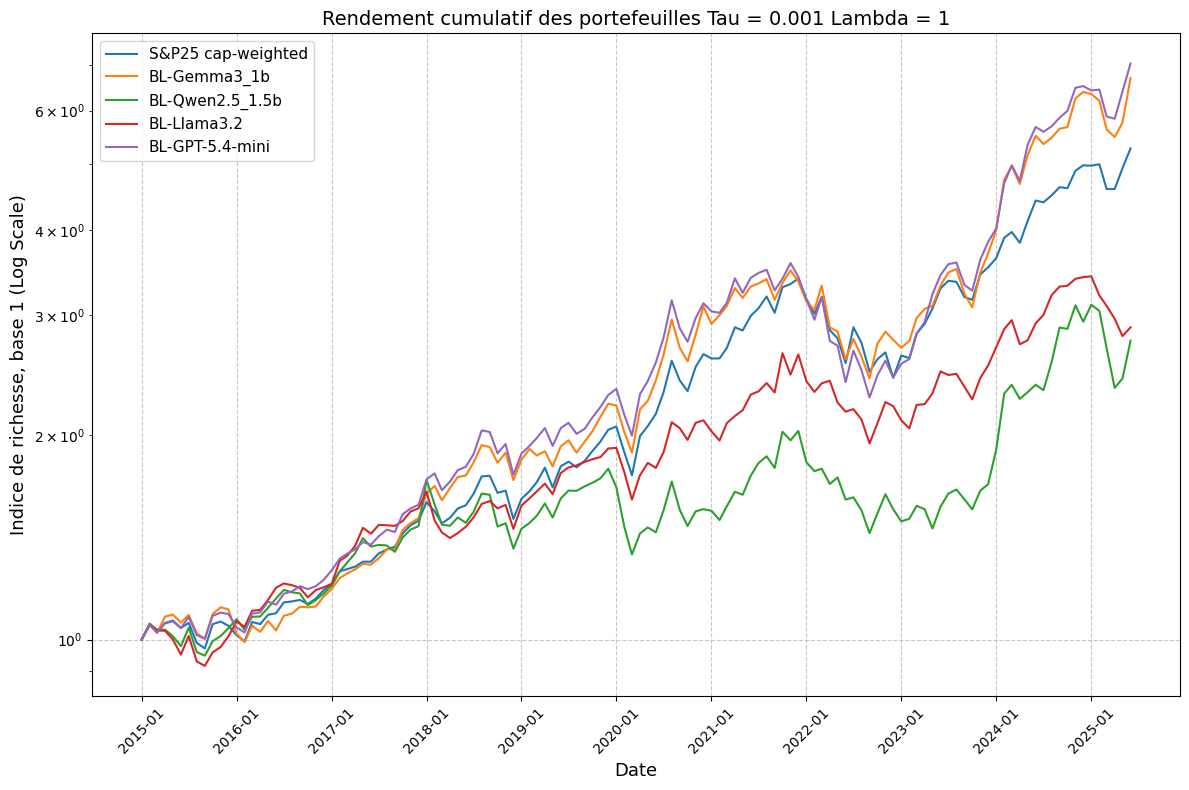

In [76]:
import matplotlib.pyplot as plt
import matplotlib

plt.figure(figsize=(12, 8))

for name, returns in portfolios.items():
    # S'assurer que toutes les séries sont comparées sur le même index mensuel
    ret = returns.reindex(common_idx).dropna().astype(float)
    # Indice de richesse : 1$ investi au début de la période
    wealth = (1 + ret).cumprod()

    # Ajouter un point initial à 1 avant le premier rendement réalisé
    first_date = wealth.index[0]

    # Comme les dates ont été standardisées au début du mois,
    # le capital initial est placé au début du mois précédent.
    if isinstance(first_date, pd.Timestamp):
        initial_date = first_date - pd.offsets.MonthBegin(1)
    else:
        initial_date = first_date - 1

    wealth = pd.concat([
        pd.Series([1.0], index=[initial_date]),
        wealth
    ])

    plt.plot(wealth.index, wealth.values, label=name)
plt.yscale('log')
plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Indice de richesse, base 1 (Log Scale)", fontsize=13)
plt.title(f"Rendement cumulatif des portefeuilles Tau = {tau} Lambda = {PORTFOLIO_RISK_AVERSION}", fontsize=14)
plt.legend(loc="upper left", fontsize=11)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
# plt.gca().xaxis.set_major_locator(matplotlib.dates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
# plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


